# Notebook 04 — Modèle ML Régression

**Objectif** : Prédire le prix par cup (`prix_cup`) d'un fruit ou légume.

**Approche** : Benchmark de 5 modèles de régression + optimisation Grid Search du meilleur.

**Fichier** : `fruits_legumes_enrichi.csv` — 710 lignes, 5 années (2013-2023)

**Plan du notebook :**
1. Chargement et préparation des features
2. Split Train / Test
3. Benchmark 5 modèles
4. Visualisation des résultats
5. Cross-validation — vérification de l'overfitting
6. Grid Search — optimisation des hyperparamètres
7. Export du modèle optimisé

In [1]:
# ── Imports et configuration ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LinearRegression, Ridge
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from xgboost                 import XGBRegressor
import joblib, json

ROUGE = '#C0392B'
BLEU  = '#3498DB'
VERT  = '#2ECC71'

print('OK — bibliothèques chargées')

OK — bibliothèques chargées


## 1. Chargement et préparation des features

In [2]:
# ── Chargement du dataset enrichi ──
# Ce fichier est le résultat du notebook 02 — 710 lignes × 24 colonnes
df = pd.read_csv('../DATA/CLEAN/fruits_legumes_enrichi.csv', sep=';', encoding='utf-8')

print(f'Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head(3)

Dataset : 710 lignes x 24 colonnes


,produit,forme,prix_detail,rendement,taille_cup,prix_cup,categorie,annee,forme_encoded,categorie_encoded,...,jours_gel,jours_chaleur,precip_totale,prix_diesel,prix_electricite,urea,dap,tsp,mop,prix_bls
0,Watermelon,Fresh,0.3334,0.520000,0.330693,0.2120,fruit,2013,0,1,...,6.0,1.0,511.2,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
1,Turnip greens,Frozen,1.4730,0.776027,0.352740,0.6696,legume,2013,2,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536
2,Turnip greens,Fresh,2.4717,0.750000,0.319670,1.0535,legume,2013,0,0,...,6.0,74.0,142.1,4.2421,14.3,304.0,474.0,390.0,355.0,1.536


In [3]:
# ── Sélection des features pour le modèle ML ──
# On garde les 12 features les plus pertinentes selon l'analyse EDA
FEATURES_ML = [
    'prix_detail',       # Prix en rayon ($/lb) — feature la plus importante
    'rendement',         # Part utilisable après préparation (0 à 1)
    'taille_cup',        # Taille de la portion standard (en livres)
    'forme_encoded',     # Forme : Fresh=0, Canned=1, Frozen=2, Juice=3, Dried=4
    'categorie_encoded', # Catégorie : fruit=1, légume=0
    'annee',             # Année de la mesure (2013 à 2023)
    'production_lbs',    # Volume de production de l'état producteur (lbs)
    'temp_moyenne',      # Température moyenne de la zone de production (°C)
    'jours_gel',         # Nombre de jours de gel par an
    'prix_diesel',       # Prix du diesel dans la région ($/gallon)
    'prix_electricite',  # Prix de l'électricité (centimes/kWh)
    'urea',              # Prix de l'urée (engrais) — $/tonne
]

# Variable cible : le prix par cup equivalent
CIBLE = 'prix_cup'

# On retire les lignes avec des NaN sur les features retenues
df_ml = df[FEATURES_ML + [CIBLE]].dropna()

# Vérification des features disponibles
features_ok = [f for f in FEATURES_ML if f in df_ml.columns]

print(f'Features retenues  : {len(features_ok)}')
print(f'Lignes disponibles : {df_ml.shape[0]}')
print(f'Variable cible     : {CIBLE}')
print(f'Prix min : {df_ml[CIBLE].min():.4f}$ | Prix max : {df_ml[CIBLE].max():.4f}$ | Prix moy : {df_ml[CIBLE].mean():.4f}$')

Features retenues  : 12
Lignes disponibles : 710
Variable cible     : prix_cup
Prix min : 0.1745$ | Prix max : 4.2792$ | Prix moy : 0.8629$


## 2. Split Train / Test

In [4]:
# ── Séparation des données en jeu d'entraînement et jeu de test ──
X = df_ml[features_ok]
y = df_ml[CIBLE]

# Split 80% entraînement / 20% test
# random_state=42 garantit la reproductibilité des résultats
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]} lignes (80%)')
print(f'Test  : {X_test.shape[0]} lignes (20%)')

# Normalisation — obligatoire pour LinearRegression et Ridge
# Les arbres (Random Forest, XGBoost) n'en ont pas besoin
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train : 568 lignes (80%)
Test  : 142 lignes (20%)


## 3. Benchmark 5 modèles

In [5]:
# ── Définition des 5 modèles à comparer ──
# True = utiliser les données normalisées, False = données brutes
MODELES = {
    'Linear Regression' : (LinearRegression(),                           True),
    'Ridge'             : (Ridge(alpha=1.0),                             True),
    'Random Forest'     : (RandomForestRegressor(n_estimators=100,
                                                 random_state=42),       False),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=100,
                                                     random_state=42),   False),
    'XGBoost'           : (XGBRegressor(n_estimators=100,
                                        random_state=42,
                                        verbosity=0),                    False),
}

resultats = []

# ── Entraînement et évaluation de chaque modèle ──
for nom, (modele, normalise) in MODELES.items():
    X_tr = X_train_sc if normalise else X_train
    X_te = X_test_sc  if normalise else X_test

    modele.fit(X_tr, y_train)
    y_pred = modele.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    resultats.append({'Modele': nom, 'RMSE': round(rmse, 4),
                      'MAE': round(mae, 4), 'R2': round(r2, 4)})
    print(f'{nom:<22} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

# ── Classement final ──
df_resultats = pd.DataFrame(resultats).sort_values('RMSE').reset_index(drop=True)
print('\nClassement (RMSE plus bas = meilleur) :')
print(df_resultats.to_string(index=False))

Linear Regression      RMSE=0.3576  MAE=0.2427  R2=0.6007
Ridge                  RMSE=0.3577  MAE=0.2425  R2=0.6005
Random Forest          RMSE=0.1056  MAE=0.0537  R2=0.9652
Gradient Boosting      RMSE=0.0925  MAE=0.0473  R2=0.9733
XGBoost                RMSE=0.0886  MAE=0.0451  R2=0.9755

Classement (RMSE plus bas = meilleur) :
           Modele   RMSE    MAE     R2
          XGBoost 0.0886 0.0451 0.9755
Gradient Boosting 0.0925 0.0473 0.9733
    Random Forest 0.1056 0.0537 0.9652
Linear Regression 0.3576 0.2427 0.6007
            Ridge 0.3577 0.2425 0.6005


## 4. Visualisation du benchmark

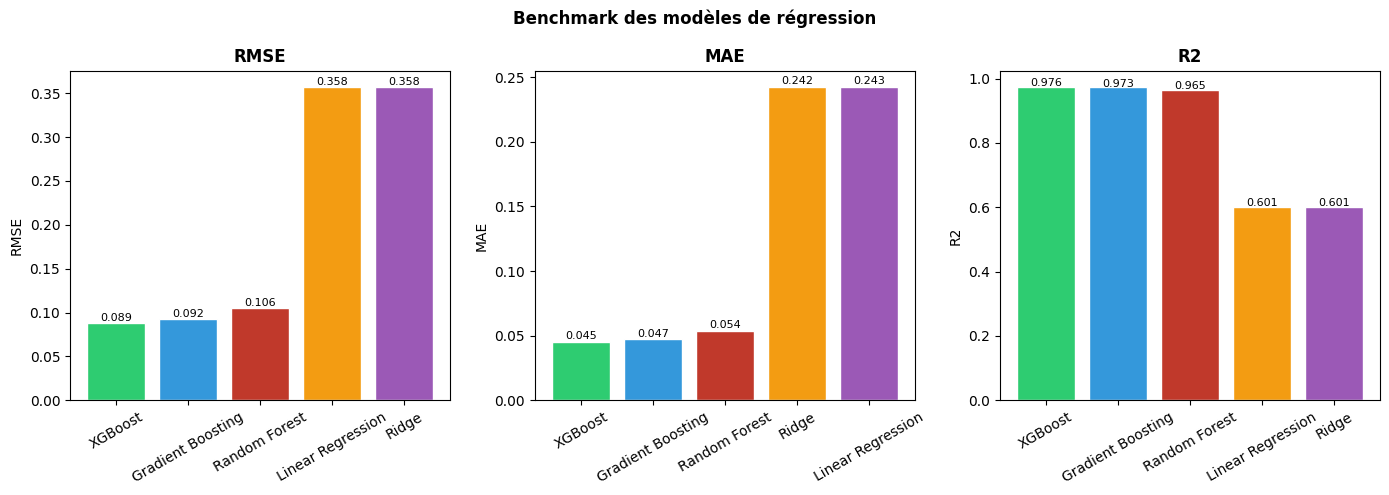

In [6]:
# ── Graphiques comparatifs des 5 modèles ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
couleurs  = [VERT, BLEU, ROUGE, '#F39C12', '#9B59B6']

for i, metrique in enumerate(['RMSE', 'MAE', 'R2']):
    df_plot = df_resultats.sort_values(
        metrique, ascending=(metrique != 'R2'))
    axes[i].bar(df_plot['Modele'], df_plot[metrique],
                color=couleurs[:len(df_plot)], edgecolor='white')
    axes[i].set_title(f'{metrique}', fontweight='bold')
    axes[i].set_ylabel(metrique)
    axes[i].tick_params(axis='x', rotation=30)
    for j, val in enumerate(df_plot[metrique]):
        axes[i].text(j, val + 0.002, f'{val:.3f}',
                     ha='center', fontsize=8)

plt.suptitle('Benchmark des modèles de régression', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Cross-validation — vérification de l'overfitting

In [7]:
# ── Cross-validation à 5 folds sur le meilleur modèle ──
# La cross-validation découpe les données en 5 parties
# et entraîne le modèle 5 fois sur des sous-ensembles différents
# Si le R2 moyen est proche du R2 du test → pas d'overfitting
# Si le R2 chute beaucoup → le modèle a mémorisé les données d'entraînement

meilleur_nom    = df_resultats.iloc[0]['Modele']
meilleur_modele = MODELES[meilleur_nom][0]
normalise       = MODELES[meilleur_nom][1]
X_cv            = X_train_sc if normalise else X_train

scores = cross_val_score(meilleur_modele, X_cv, y_train,
                         cv=5, scoring='r2')

print(f'Cross-validation 5 folds — {meilleur_nom}')
print(f'  Scores  : {scores.round(3)}')
print(f'  Moyenne : {scores.mean():.4f}')
print(f'  Std     : {scores.std():.4f}')
print(f'  R2 test : {df_resultats.iloc[0]["R2"]}')
print()

diff = abs(scores.mean() - df_resultats.iloc[0]['R2'])
if diff < 0.05:
    print(f'Diagnostic : pas d overfitting (écart = {diff:.4f} < seuil 0.05)')
elif diff < 0.15:
    print(f'Diagnostic : léger overfitting (écart = {diff:.4f})')
else:
    print(f'Diagnostic : overfitting probable (écart = {diff:.4f} > 0.15)')

Cross-validation 5 folds — XGBoost
  Scores  : [0.949 0.965 0.947 0.968 0.952]
  Moyenne : 0.9562
  Std     : 0.0087
  R2 test : 0.9755

Diagnostic : pas d overfitting (écart = 0.0193 < seuil 0.05)


## 6. Grid Search — Optimisation des hyperparamètres XGBoost

In [8]:
# ── Grid Search — recherche des meilleurs hyperparamètres ──
# Un hyperparamètre c'est un réglage du modèle qu'on choisit avant l'entraînement
# GridSearchCV teste toutes les combinaisons possibles et retourne la meilleure

from sklearn.model_selection import GridSearchCV

# Grille des paramètres à tester
param_grid = {
    'n_estimators'    : [100, 200, 300],     # Nombre d'arbres dans la forêt
    'max_depth'       : [3, 5, 7],           # Profondeur maximale de chaque arbre
    'learning_rate'   : [0.01, 0.05, 0.1],  # Vitesse d'apprentissage
    'subsample'       : [0.8, 1.0],          # Pourcentage de lignes utilisées par arbre
    'colsample_bytree': [0.8, 1.0],          # Pourcentage de colonnes utilisées par arbre
}

nb_combinaisons = 1
for v in param_grid.values():
    nb_combinaisons *= len(v)

print(f'Nombre de combinaisons à tester : {nb_combinaisons}')
print(f'Nombre de fits total (x5 folds) : {nb_combinaisons * 5}')
print('Lancement du Grid Search... (peut prendre 5 à 15 minutes)')

# GridSearchCV teste toutes les combinaisons avec cross-validation à 5 folds
grid_search = GridSearchCV(
    estimator  = XGBRegressor(random_state=42, verbosity=0),
    param_grid = param_grid,
    cv         = 5,       # 5 folds de cross-validation
    scoring    = 'r2',    # On optimise le R²
    n_jobs     = -1,      # Utilise tous les coeurs du PC pour aller plus vite
    verbose    = 1        # Affiche la progression
)

grid_search.fit(X_train, y_train)

print(f'\nMeilleurs paramètres trouvés :')
for param, valeur in grid_search.best_params_.items():
    print(f'  {param:<20} : {valeur}')

print(f'\nMeilleur R² cross-validation : {grid_search.best_score_:.4f}')

Nombre de combinaisons à tester : 108
Nombre de fits total (x5 folds) : 540
Lancement du Grid Search... (peut prendre 5 à 15 minutes)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs paramètres trouvés :
  colsample_bytree     : 1.0
  learning_rate        : 0.1
  max_depth            : 3
  n_estimators         : 300
  subsample            : 0.8

Meilleur R² cross-validation : 0.9815


In [9]:
# ── Évaluation du modèle optimisé sur le jeu de test ──

# On récupère le meilleur modèle trouvé par le Grid Search
modele_optimise = grid_search.best_estimator_

# Prédiction sur les données de test
y_pred_gs = modele_optimise.predict(X_test)

# Calcul des métriques
r2_gs   = r2_score(y_test, y_pred_gs)
rmse_gs = np.sqrt(mean_squared_error(y_test, y_pred_gs))
mae_gs  = mean_absolute_error(y_test, y_pred_gs)

print('Résultats sur le jeu de test :')
print(f'  R²   = {r2_gs:.4f}')
print(f'  RMSE = {rmse_gs:.4f} $/cup')
print(f'  MAE  = {mae_gs:.4f} $/cup')

Résultats sur le jeu de test :
  R²   = 0.9782
  RMSE = 0.0835 $/cup
  MAE  = 0.0355 $/cup


In [10]:
# ── Tableau comparatif : modèle de base vs modèle optimisé ──

# Récupération des résultats du modèle de base
r2_base   = df_resultats[df_resultats['Modele'] == 'XGBoost']['R2'].values[0]
rmse_base = df_resultats[df_resultats['Modele'] == 'XGBoost']['RMSE'].values[0]
mae_base  = df_resultats[df_resultats['Modele'] == 'XGBoost']['MAE'].values[0]

print(f'{"Modèle":<28} {"R²":>8} {"RMSE":>10} {"MAE":>10}')
print('-' * 58)
print(f'{"XGBoost baseline (n=100)":<28} {r2_base:>8.4f} {rmse_base:>10.4f} {mae_base:>10.4f}')
print(f'{"XGBoost Grid Search":<28} {r2_gs:>8.4f} {rmse_gs:>10.4f} {mae_gs:>10.4f}')
print()

amelioration_r2   = (r2_gs   - r2_base)   * 100
amelioration_rmse = (rmse_base - rmse_gs)

print(f'Amélioration R²   : +{amelioration_r2:.2f} points')
print(f'Amélioration RMSE : -{amelioration_rmse*100:.2f} centimes/cup')
print(f'\nParamètres retenus : {grid_search.best_params_}')

Modèle                             R²       RMSE        MAE
----------------------------------------------------------
XGBoost baseline (n=100)       0.9755     0.0886     0.0451
XGBoost Grid Search            0.9782     0.0835     0.0355

Amélioration R²   : +0.27 points
Amélioration RMSE : -0.51 centimes/cup

Paramètres retenus : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


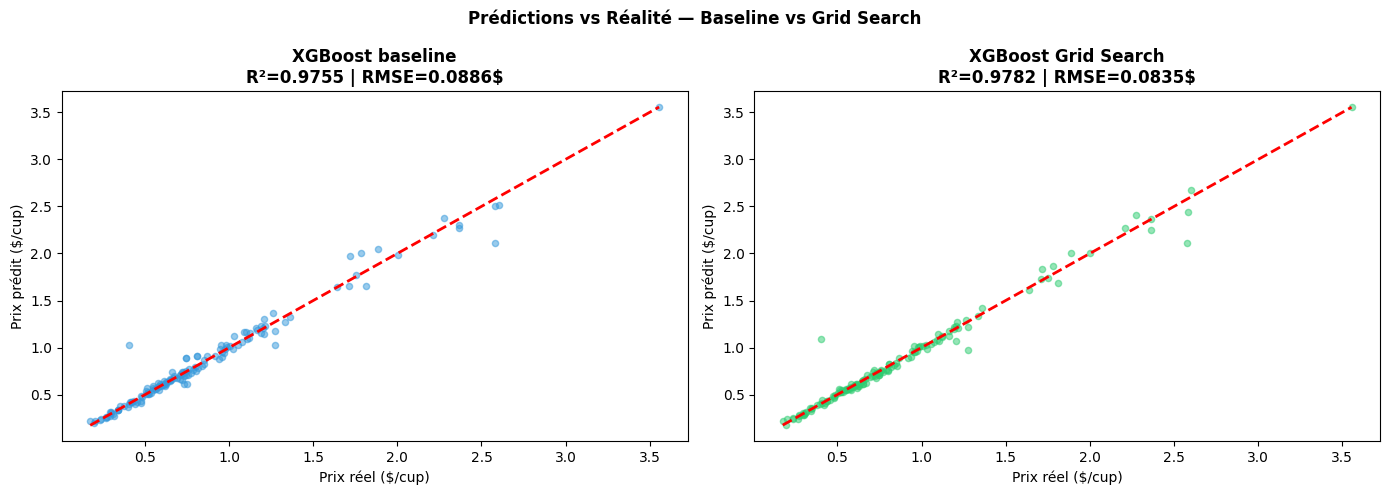

In [11]:
# ── Visualisation : prédictions vs réalité ──
# Ce graphique montre à quel point le modèle prédit correctement
# Les points proches de la diagonale = bonnes prédictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modèle de base
modele_base = MODELES['XGBoost'][0]
y_pred_base = modele_base.predict(X_test)

axes[0].scatter(y_test, y_pred_base, alpha=0.5, color=BLEU, s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Prix réel ($/cup)')
axes[0].set_ylabel('Prix prédit ($/cup)')
axes[0].set_title(f'XGBoost baseline\nR²={r2_base:.4f} | RMSE={rmse_base:.4f}$',
                  fontweight='bold')

# Modèle optimisé
axes[1].scatter(y_test, y_pred_gs, alpha=0.5, color=VERT, s=20)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Prix réel ($/cup)')
axes[1].set_ylabel('Prix prédit ($/cup)')
axes[1].set_title(f'XGBoost Grid Search\nR²={r2_gs:.4f} | RMSE={rmse_gs:.4f}$',
                  fontweight='bold')

plt.suptitle('Prédictions vs Réalité — Baseline vs Grid Search', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Export du modèle optimisé

In [12]:
# ── Export du modèle optimisé en fichier .pkl ──
# Le fichier .pkl sauvegarde le modèle entraîné sur le disque
# FastAPI charge ce fichier au démarrage pour faire des prédictions sans ré-entraîner

import joblib, json, os

# Chemin de sauvegarde
os.makedirs('../models', exist_ok=True)
chemin_pkl      = '../models/xgboost_fruits_legumes.pkl'
chemin_features = '../models/features.json'

# Sauvegarde du modèle
joblib.dump(modele_optimise, chemin_pkl)

# Sauvegarde de la liste ordonnée des features
# Important : FastAPI doit envoyer les features dans le même ordre
features_config = {"features": features_ok}
with open(chemin_features, 'w', encoding='utf-8') as f:
    json.dump(features_config, f, indent=2)

taille = os.path.getsize(chemin_pkl) / 1024
print(f'Modèle exporté avec succès !')
print(f'  Fichier : {chemin_pkl}')
print(f'  Taille  : {taille:.1f} Ko')
print(f'  R²      : {r2_gs:.4f}')
print(f'  RMSE    : {rmse_gs:.4f} $/cup')
print(f'  MAE     : {mae_gs:.4f} $/cup')
print(f'  Params  : {grid_search.best_params_}')

Modèle exporté avec succès !
  Fichier : ../models/xgboost_fruits_legumes.pkl
  Taille  : 332.6 Ko
  R²      : 0.9782
  RMSE    : 0.0835 $/cup
  MAE     : 0.0355 $/cup
  Params  : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}


In [13]:
# ── Vérification : rechargement et test du modèle exporté ──
# On recharge le fichier .pkl et on vérifie que les résultats sont identiques

modele_recharge = joblib.load(chemin_pkl)
y_pred_verif    = modele_recharge.predict(X_test)
r2_verif        = r2_score(y_test, y_pred_verif)

print(f'Vérification après rechargement :')
print(f'  R² original  : {r2_gs:.4f}')
print(f'  R² rechargé  : {r2_verif:.4f}')

if abs(r2_gs - r2_verif) < 0.0001:
    print('Export validé — le modèle rechargé donne les mêmes résultats')
else:
    print('Attention — différence détectée entre original et rechargé')

Vérification après rechargement :
  R² original  : 0.9782
  R² rechargé  : 0.9782
Export validé — le modèle rechargé donne les mêmes résultats


## Bilan du notebook

**Ce notebook a réalisé :**
- Chargement du dataset enrichi (710 lignes × 24 colonnes)
- Sélection de 12 features pertinentes
- Split 80% train / 20% test (random_state=42)
- Benchmark de 5 modèles de régression
- Cross-validation à 5 folds pour vérifier l'absence d'overfitting
- Grid Search sur XGBoost : 108 combinaisons × 5 folds = 540 fits
- Export du modèle optimisé en fichier .pkl

**Résultats finaux :**
- Modèle retenu : XGBoost optimisé par Grid Search
- R² = 0.9782 (contre 0.9755 pour le baseline)
- RMSE = 0.0835 $/cup (contre 0.0886 pour le baseline)
- Paramètres : n_estimators=300, max_depth=3, learning_rate=0.1, subsample=0.8

**Prochaine étape :** Notebook 05 — Export SHAP et interprétabilité